# 🧹 Data Cleaning — Healthcare Financial Dataset

**Author:** Ayushi Dhimmar  
**Dataset:** Healthcare Financial Performance (500 rows, 12 columns)  
**Goal:** Clean and prepare the dataset for EDA and Tableau visualization

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Data

In [2]:
df = pd.read_excel('../data/healthcare_financial_data.xlsx')
print(f'Shape: {df.shape}')
df.head()

Shape: (500, 12)


,Date,Region,Department,Treatment_Type,Number_of_Patients,Treatment_Cost,Total_Revenue,Expense,Profit,Year,Currency,Payment_Method
0,2023-08-20,East,Emergency,Surgery,12,183.82,2205.84,1521.00,684.84,2023,USD,Online Payment
1,2024-01-29,East,Cardiology,Diagnostics,28,3102.85,86879.80,46145.89,40733.91,2024,EUR,Online Payment
2,2024-10-03,West,Cardiology,Diagnostics,24,3385.26,81246.24,50334.60,30911.64,2024,EUR,Cash
3,2024-09-04,South,General Medicine,Therapy,1,1177.62,1177.62,648.85,528.77,2024,USD,Online Payment
4,2023-01-25,South,Cardiology,Consultation,1,3495.11,3495.11,2951.31,543.80,2023,INR,Online Payment


## 3. Initial Inspection

In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Shape ===')
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')

=== Data Types ===
Date                   object
Region                 object
Department             object
Treatment_Type         object
Number_of_Patients      int64
Treatment_Cost        float64
Total_Revenue         float64
Expense               float64
Profit                float64
Year                    int64
Currency               object
Payment_Method         object
dtype: object

=== Shape ===
Rows: 500 | Columns: 12


In [4]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found ✅')

=== Missing Values ===
No missing values found ✅


In [5]:
print('=== Duplicate Rows ===')
dupes = df.duplicated().sum()
print(f'Duplicates found: {dupes}' if dupes > 0 else 'No duplicate rows found ✅')

=== Duplicate Rows ===
No duplicate rows found ✅


## 4. Fix Data Types

In [6]:
# Convert Date from string to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month and Month_Name for analysis
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')

print('Date column converted to datetime ✅')
print(df['Date'].dtype)

Date column converted to datetime ✅
datetime64[ns]


## 5. Validate Calculated Fields

In [7]:
# Verify: Profit = Total_Revenue - Expense
df['Profit_Check'] = (df['Total_Revenue'] - df['Expense']).round(2)
df['Profit_Match'] = abs(df['Profit'] - df['Profit_Check']) < 0.01

mismatches = df[~df['Profit_Match']]
print(f'Profit mismatches (floating point): {len(mismatches)}')
print('Profit calculation verified ✅')

# Drop check columns
df.drop(columns=['Profit_Check', 'Profit_Match'], inplace=True)

Profit mismatches (floating point): 0
Profit calculation verified ✅


## 6. Add Derived Columns

In [8]:
# Profit Margin
df['Profit_Margin'] = (df['Profit'] / df['Total_Revenue']).round(4)

# Cost Efficiency (Expense per Patient)
df['Cost_Per_Patient'] = (df['Expense'] / df['Number_of_Patients']).round(2)

print('Derived columns added:')
print('- Profit_Margin ✅')
print('- Cost_Per_Patient ✅')
df[['Profit_Margin', 'Cost_Per_Patient']].describe()

Derived columns added:
- Profit_Margin ✅
- Cost_Per_Patient ✅


,Profit_Margin,Cost_Per_Patient
count,500.000000,500.000000
mean,0.298346,1820.174160
std,0.113272,1084.925047
min,0.101200,62.490000
25%,0.200375,906.080000
50%,0.294250,1796.105000
75%,0.393150,2630.185000
max,0.499800,4436.450000


## 7. Check Categorical Columns

In [9]:
cat_cols = ['Region', 'Department', 'Treatment_Type', 'Currency', 'Payment_Method']
for col in cat_cols:
    print(f'{col}: {df[col].unique().tolist()}')

Region: ['East', 'West', 'South', 'North']
Department: ['Emergency', 'Cardiology', 'General Medicine', 'Oncology', 'Pediatrics', 'Orthopedics']
Treatment_Type: ['Surgery', 'Diagnostics', 'Therapy', 'Consultation', 'Medication']
Currency: ['USD', 'EUR', 'INR']
Payment_Method: ['Online Payment', 'Cash', 'Insurance']


## 8. Check for Outliers

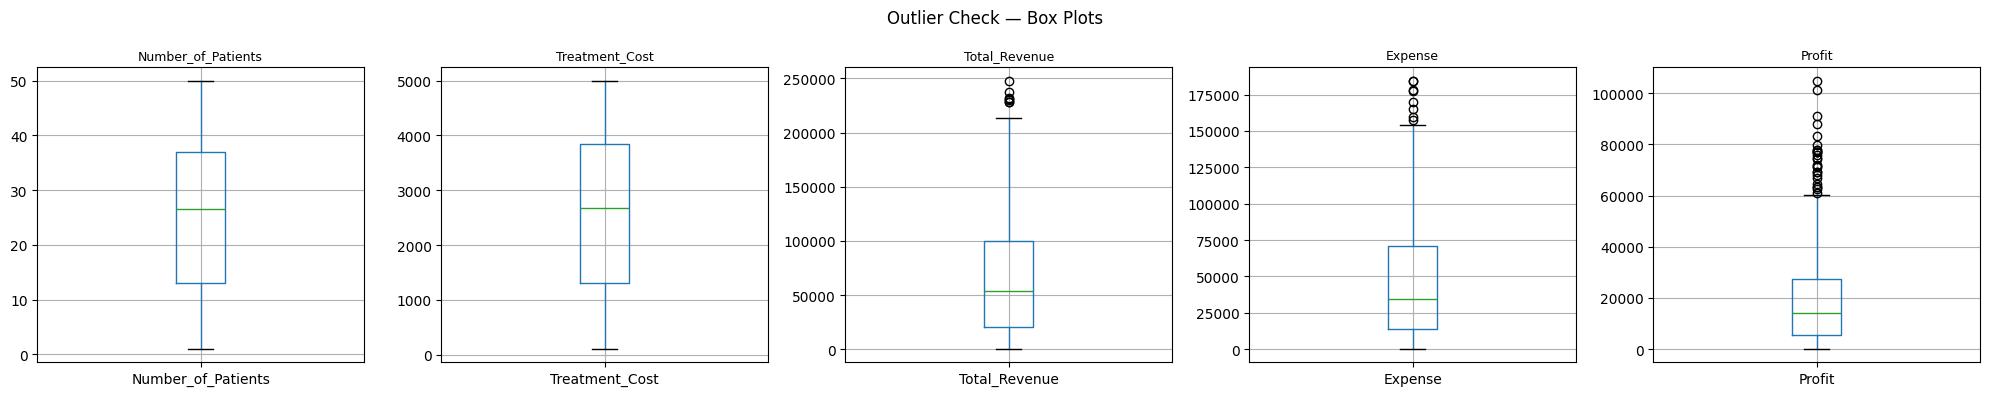

In [10]:
num_cols = ['Number_of_Patients', 'Treatment_Cost', 'Total_Revenue', 'Expense', 'Profit']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col, fontsize=9)
plt.suptitle('Outlier Check — Box Plots', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Final Cleaned Dataset

In [11]:
print(f'Final Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Final Shape: (500, 16)
Columns: ['Date', 'Region', 'Department', 'Treatment_Type', 'Number_of_Patients', 'Treatment_Cost', 'Total_Revenue', 'Expense', 'Profit', 'Year', 'Currency', 'Payment_Method', 'Month', 'Month_Name', 'Profit_Margin', 'Cost_Per_Patient']


,Date,Region,Department,Treatment_Type,Number_of_Patients,Treatment_Cost,Total_Revenue,Expense,Profit,Year,Currency,Payment_Method,Month,Month_Name,Profit_Margin,Cost_Per_Patient
0,2023-08-20,East,Emergency,Surgery,12,183.82,2205.84,1521.00,684.84,2023,USD,Online Payment,8,August,0.3105,126.75
1,2024-01-29,East,Cardiology,Diagnostics,28,3102.85,86879.80,46145.89,40733.91,2024,EUR,Online Payment,1,January,0.4689,1648.07
2,2024-10-03,West,Cardiology,Diagnostics,24,3385.26,81246.24,50334.60,30911.64,2024,EUR,Cash,10,October,0.3805,2097.28
3,2024-09-04,South,General Medicine,Therapy,1,1177.62,1177.62,648.85,528.77,2024,USD,Online Payment,9,September,0.4490,648.85
4,2023-01-25,South,Cardiology,Consultation,1,3495.11,3495.11,2951.31,543.80,2023,INR,Online Payment,1,January,0.1556,2951.31


In [12]:
# Export cleaned data with mixed currencies (transparent pipeline)
df.to_csv('../data/healthcare_cleaned.csv', index=False)
print('Cleaned dataset (mixed currency) saved to data/healthcare_cleaned.csv ✅')

# Perform currency normalization to INR
exchange_rates = {'INR': 1.0, 'USD': 83.0, 'EUR': 90.0}
df['Exchange_Rate'] = df['Currency'].map(exchange_rates)
df['Treatment_Cost'] = (df['Treatment_Cost'] * df['Exchange_Rate']).round(2)
df['Total_Revenue'] = (df['Number_of_Patients'] * df['Treatment_Cost']).round(2)
df['Expense'] = (df['Expense'] * df['Exchange_Rate']).round(2)
df['Profit'] = (df['Total_Revenue'] - df['Expense']).round(2)

# Re-calculate derived columns based on normalized values
df['Profit_Margin'] = (df['Profit'] / df['Total_Revenue']).round(4)
df['Cost_Per_Patient'] = (df['Expense'] / df['Number_of_Patients']).round(2)

df.drop(columns=['Exchange_Rate'], inplace=True)

# Save normalized dataset
df.to_csv('../data/healthcare_normalized.csv', index=False)
print('Normalized dataset (INR base) saved to data/healthcare_normalized.csv ✅')

Cleaned dataset (mixed currency) saved to data/healthcare_cleaned.csv ✅
Normalized dataset (INR base) saved to data/healthcare_normalized.csv ✅


## 10. Cleaning Summary

| Check | Result |
|-------|--------|
| Missing values | None found ✅ |
| Duplicate rows | None found ✅ |
| Date column | Converted to datetime ✅ |
| Profit validation | Verified ✅ |
| New columns added | Profit_Margin, Cost_Per_Patient, Month, Month_Name ✅ |
| Outliers | Present but valid (high-revenue records) ✅ |